In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

2026-06-01 00:24:54.221791: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
ticker = "AAPL"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01"
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511059,24.042132,23.325184,23.962471,257142000
2015-01-06,23.513277,23.772175,23.152589,23.575235,263188400
2015-01-07,23.842968,23.942544,23.610623,23.721263,160423600
2015-01-08,24.759079,24.816612,24.053194,24.170474,237458000


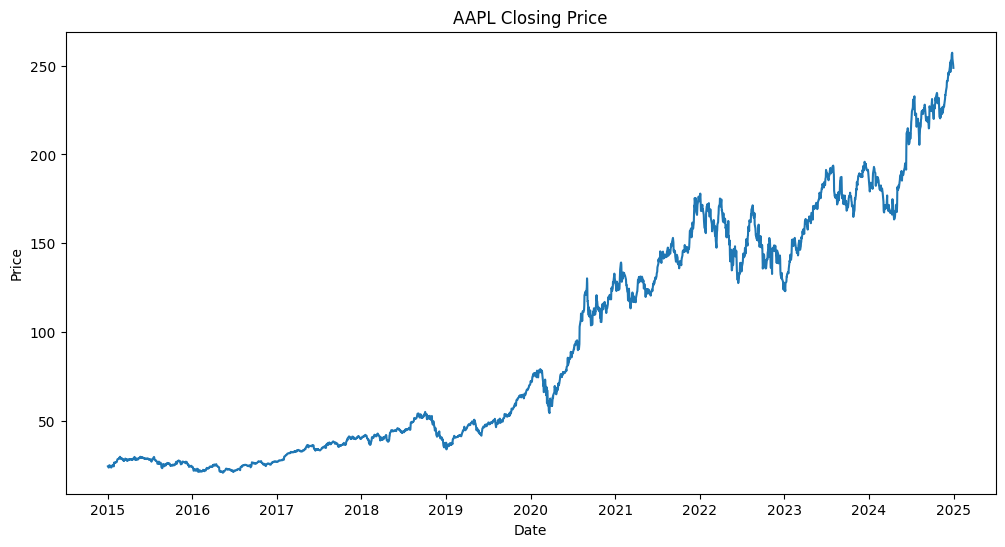

In [ ]:
# Visualize Data
plt.figure(figsize=(12,6))
plt.plot(df["Close"])
plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [16]:

#Prepare Data

data = df[["Close"]]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [17]:
# create seq of 60 timesteps to predict one future day

X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X.shape

(2456, 60)

In [ ]:
# reahape to be [samples, time steps, features]
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

X.shape

(2456, 60, 1)

In [ ]:
# Train/Test Split

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
# Build LSTM Model
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        50,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - loss: 0.0091 - val_loss: 7.1747e-04
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0011 - val_loss: 8.9042e-04
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 8.0272e-04 - val_loss: 0.0031
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 8.6411e-04 - val_loss: 0.0016
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 7.1798e-04 - val_loss: 0.0010
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 7.9771e-04 - val_loss: 7.7617e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 6.5918e-04 - val_loss: 0.0012
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 6.4973e-04 - val_loss: 0.0012
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 5.3625e-04 - val_loss: 0.0015
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 5.4763e-04 - val_loss: 0.0029
Epoch 12/20
62/6

In [23]:
# Predict
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


In [ ]:
# Evaluate
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 6.618351413459406


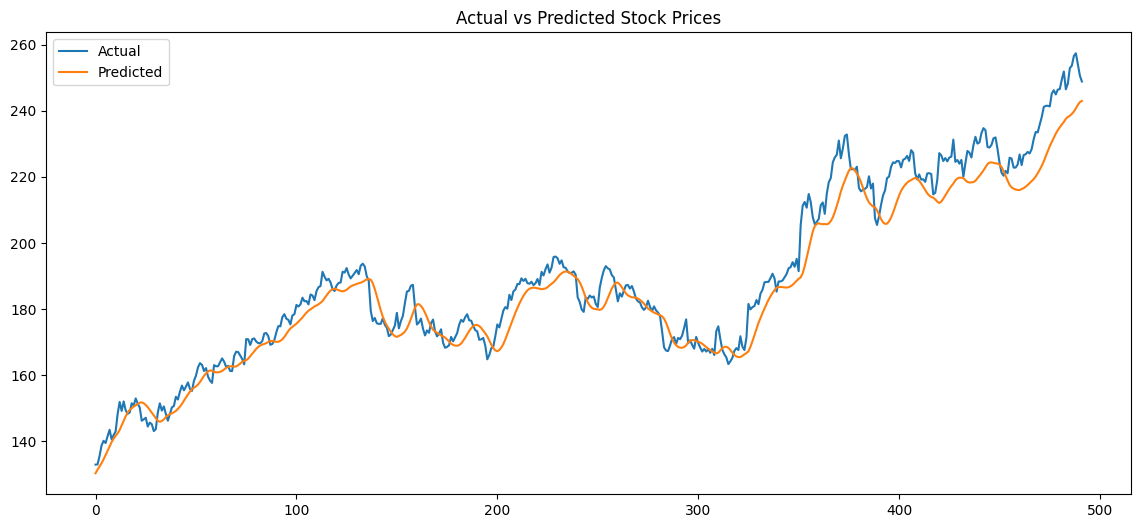

In [ ]:
# Plot Results

plt.figure(figsize=(14,6))

plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.show()

In [ ]:
# Predict Tomorrow's Price
last_60_days = scaled_data[-60:]

X_future = np.array([last_60_days])

prediction = model.predict(X_future)

prediction = scaler.inverse_transform(prediction)

print(
    "Predicted Next Price:",
    prediction[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Predicted Next Price: 242.78886
